<a href="https://colab.research.google.com/github/mmanishyadav325-ux/ubiquitous-couscous/blob/main/level2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Level 2**

# **Task 1**

# Task: Restaurant Ratings

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv(r'/content/Dataset .csv')
df.rename(columns={"Rating text":"Reviews"},inplace=True)
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Reviews,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [ ]:
df.shape

(9551, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

Analyze the distribution of aggregate
ratings and determine the most common
rating range.

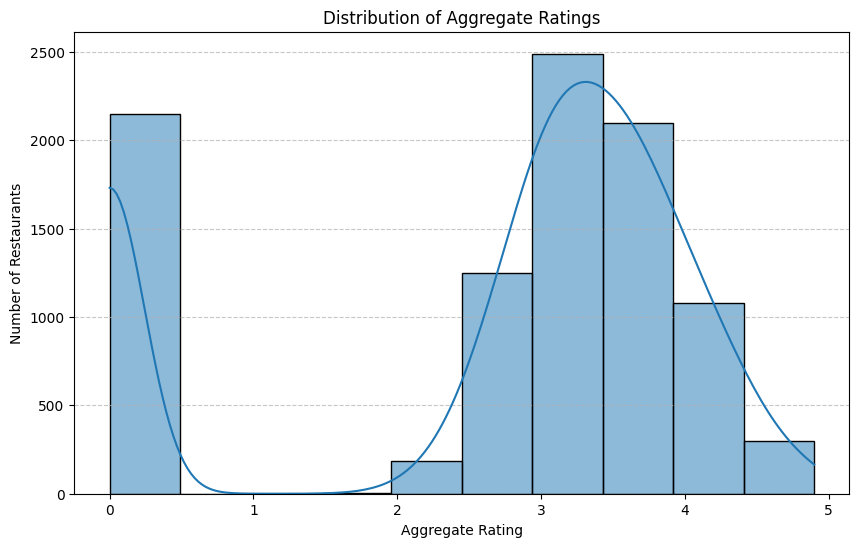

In [ ]:
# Plot the distribution of 'Aggregate rating'
plt.figure(figsize=(10, 6))
sns.histplot(df['Aggregate rating'], bins=10, kde=True)
plt.title('Distribution of Aggregate Ratings')
plt.xlabel('Aggregate Rating')
plt.ylabel('Number of Restaurants')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Calculate the average number of votes
received by restaurants.

In [ ]:
# Calculate the average number of votes
average_votes = df['Votes'].mean()
print(f"The average number of votes received by restaurants is: {average_votes:.2f}")

The average number of votes received by restaurants is: 156.91


# **Task 2**

# Task:Cuisine Combination

# Identify the most common combinations of cuisines in the dataset.

In [ ]:
common_combinations=df.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False)
top1o=common_combinations.head(10)
print("Top 10 most common combinations are :", top1o)

Top 10 most common combinations are : Cuisines
Burger, Bar Food, Steak            4.9
American, Burger, Grill            4.9
American, Caribbean, Seafood       4.9
American, Coffee and Tea           4.9
Mexican, American, Healthy Food    4.9
Italian, Bakery, Continental       4.9
BBQ, Breakfast, Southern           4.9
European, German                   4.9
Hawaiian, Seafood                  4.9
Sunda, Indonesian                  4.9
Name: Aggregate rating, dtype: float64


# Determine if certain cuisine combination tend to have higher  ratings.

In [ ]:
max_rating = common_combinations.iloc[0]
print('The Max Rating is :',max_rating)

The Max Rating is : 4.9


In [ ]:
max_rated_rest = df.loc[df['Aggregate rating']==max_rating]
print ("Restaurants having the maximum rating :",max_rated_rest["Restaurant Name"])

Restaurants having the maximum rating : 3                                           Ooma
8       Spiral - Sofitel Philippine Plaza Manila
10                              Silantro Fil-Mex
39                                    Coco Bambu
48                            Braseiro da G��vea
                          ...                   
9484              Restaurant Mosaic @ The Orient
9514                            Ministry of Crab
9524                                Gaga Manjero
9538                                   Starbucks
9540                            Draft Gastro Pub
Name: Restaurant Name, Length: 61, dtype: object


# **TASK 3**

# Task: Geographic Analysis

# Plot the locations of restaurants on amap using longitude and latitude coordinates.

In [ ]:
print(df[['Latitude','Latitude']])

       Latitude   Latitude
0     14.565443  14.565443
1     14.553708  14.553708
2     14.581404  14.581404
3     14.585318  14.585318
4     14.584450  14.584450
...         ...        ...
9546  41.022793  41.022793
9547  41.009847  41.009847
9548  41.055817  41.055817
9549  41.057979  41.057979
9550  40.984776  40.984776

[9551 rows x 2 columns]


In [ ]:
import geopandas
gdf= geopandas.GeoDataFrame(df, geometry=geopandas.points_from_xy(df.Longitude, df.Latitude))
gdf.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Reviews,Votes,geometry
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Yes,No,No,No,3,4.8,Dark Green,Excellent,314,POINT (121.02754 14.56544)
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Yes,No,No,No,3,4.5,Dark Green,Excellent,591,POINT (121.0141 14.55371)
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Yes,No,No,No,4,4.4,Green,Very Good,270,POINT (121.05683 14.5814)
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,No,No,No,No,4,4.9,Dark Green,Excellent,365,POINT (121.05648 14.58532)
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Yes,No,No,No,4,4.8,Dark Green,Excellent,229,POINT (121.05751 14.58445)


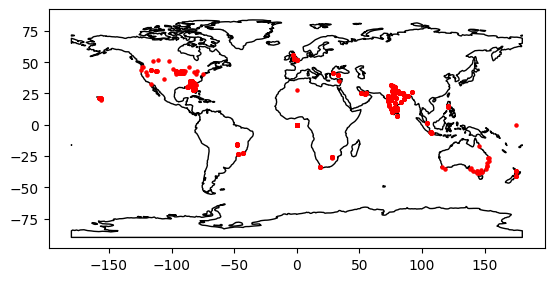

In [ ]:
!pip install geodatasets
import geopandas
import matplotlib.pyplot as plt
from geodatasets import get_path

world = geopandas.read_file(get_path("naturalearth.land"))

ax = world.plot(
    color="white",
    edgecolor="black"
)

gdf.plot(
    ax=ax,
    marker="o",
    color="red",
    markersize=5
)

plt.show()

# Identify any pattems or clusters of restaurants in specific areas.

In [ ]:
import pandas as pd
import folium

# Re-define df to ensure it's available in this cell
df=pd.read_csv(r'/content/Dataset .csv')
df.rename(columns={"Rating text":"Reviews"},inplace=True)

world_map = folium.Map(location=[df['Latitude'].mean(), df['Longitude'].mean()], zoom_start=1, height='100%', width='100%')

In [ ]:
from folium.plugins import HeatMap
heat_marker =[[row['Latitude'], row['Longitude']] for i, row in df.iterrows()]
HeatMap(heat_marker,radius=15).add_to(world_map)

In [ ]:
world_map

# **TASK 4**

# TASK:Restaurant Chains

# Identify if there are any restaurant chains present in the dataset.

In [ ]:
restaurant_chain = df.groupby('Restaurant Name').size().reset_index(name="OutletCount")
new = restaurant_chain[restaurant_chain["OutletCount"] > 1]
restaurant_chains = new.sort_values(by="OutletCount", ascending=False)

In [ ]:
print(restaurant_chains[["Restaurant Name","OutletCount"]].head(15))

       Restaurant Name  OutletCount
1098   Cafe Coffee Day           83
2098    Domino's Pizza           79
6106            Subway           63
2716  Green Chick Chop           51
4077        McDonald's           48
3478         Keventers           34
4961         Pizza Hut           30
2619             Giani           29
680     Baskin Robbins           28
663    Barbeque Nation           26
2620           Giani's           22
670            Barista           22
2145    Dunkin' Donuts           22
4924     Pind Balluchi           20
1758      Costa Coffee           20


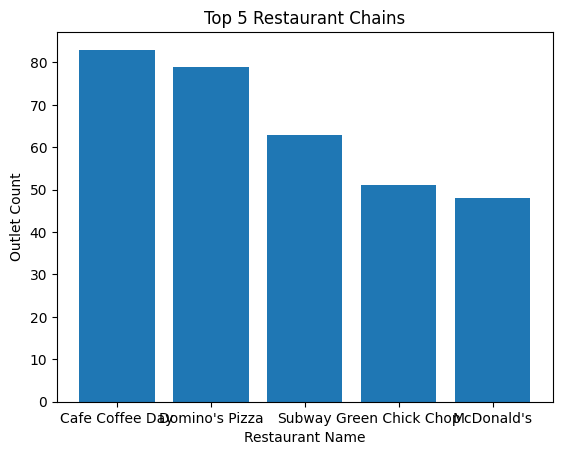

In [ ]:
import matplotlib.pyplot as plt

plt.bar(restaurant_chains["Restaurant Name"][:5],restaurant_chains["OutletCount"][:5])
plt.xlabel("Restaurant Name")
plt.ylabel("Outlet Count")
plt.title("Top 5 Restaurant Chains")

plt.show()

# Analyze the rating and popularity of different chains.

In [ ]:
ratings = df.groupby('Restaurant Name')['Aggregate rating'].mean().reset_index(name="Average Rating").sort_values(by="Average Rating", ascending=False)
print(ratings)

                               Restaurant Name  Average Rating
5946                                    Solita             4.9
6045  Spiral - Sofitel Philippine Plaza Manila             4.9
2354                                 Flat Iron             4.9
5477                     Sagar Gaire Fast Food             4.9
651                                        Bao             4.9
...                                        ...             ...
6032                             Spices Affair             0.0
6034                              Spicy Affair             0.0
6035                               Spicy Curry             0.0
757                            Bhashi Caterers             0.0
761                         Bhawani Restaurant             0.0

[7446 rows x 2 columns]


In [ ]:
votes =df.groupby('Restaurant Name')['Votes'].sum().reset_index(name="Total Votes").sort_values(by="Total Votes", ascending=False)
print(votes)

                 Restaurant Name  Total Votes
663              Barbeque Nation        28142
101    AB's - Absolute Barbecues        13400
6943                        Toit        10934
785                    Big Chill        10853
2297                  Farzi Cafe        10098
...                          ...          ...
2525  Frugurpop-  ibis New Delhi            0
2522               Frozen Grillz            0
953          Break Fast Junction            0
4959                   Pizza Hot            0
4949              Piyu Fast Food            0

[7446 rows x 2 columns]


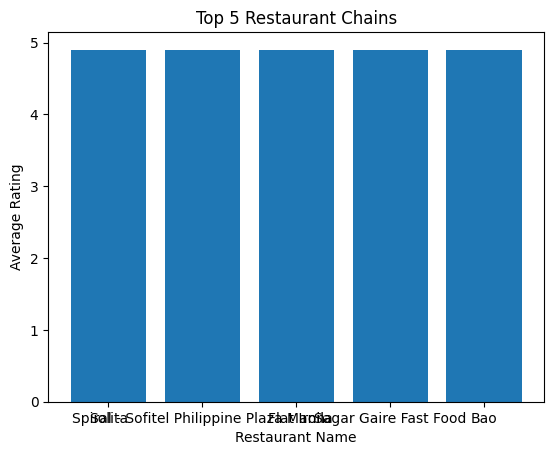

In [ ]:
plt.bar(ratings["Restaurant Name"][:5],ratings["Average Rating"][:5])
plt.xlabel("Restaurant Name")
plt.ylabel("Average Rating")
plt.title("Top 5 Restaurant Chains")

plt.show()